In [6]:
import pandas as pd

# On charge ton fichier CSV en précisant le bon alphabet (encoding='latin-1')
df = pd.read_csv('player_stats.csv', encoding='latin-1')

# On affiche les 5 premières lignes
df.head()

,player,country,height,weight,age,club,ball_control,dribbling,marking,slide_tackle,...,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes,value
0,Cristian Castro Devenish,Colombia,192,84,22,Atl. Nacional,55,43,NaN,68,...,32,34,41,33,10,11,6,7,9,$1.400.000
1,Silaldo Taffarel,Brazil,181,80,31,Corinthians,69,70,NaN,56,...,65,62,48,46,12,15,14,8,14,$975.00
2,Thomas DÃ¤hne,Germany,193,84,29,Holstein Kiel,25,12,NaN,13,...,20,15,26,16,64,74,65,68,74,$1.100.000
3,Michael Sollbauer,Austria,187,86,33,SK Rapid Wien,46,48,NaN,66,...,25,13,22,19,10,10,8,14,9,$650.00
4,Diego Segovia,Uruguay,191,80,23,Independiente,14,8,NaN,14,...,9,10,16,5,61,59,62,64,64,$300.00


In [19]:
# 1. On supprime la colonne "marking" (avec la sécurité anti-bug)
df = df.drop(columns=['marking'], errors='ignore')

# 2. On nettoie la colonne "value" : on enlève le "$" et les "."
df['value'] = df['value'].astype(str).str.replace('$', '', regex=False)
df['value'] = df['value'].str.replace('.', '', regex=False)

# 3. On transforme le texte restant en vrais nombres (float)
df['value'] = df['value'].astype(float)

# On affiche un résumé pour voir si ça a marché
df[['player', 'club', 'value']].head()

,player,club,value
0,Cristian Castro Devenish,Atl. Nacional,1400000.0
1,Silaldo Taffarel,Corinthians,97500.0
2,Thomas DÃ¤hne,Holstein Kiel,1100000.0
3,Michael Sollbauer,SK Rapid Wien,65000.0
4,Diego Segovia,Independiente,30000.0


/var/folders/kt/5xcr79v95tl2kd96zbl6rfdw0000gn/T/ipykernel_53989/1755387421.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_clubs.values, y=top_clubs.index, palette="viridis")


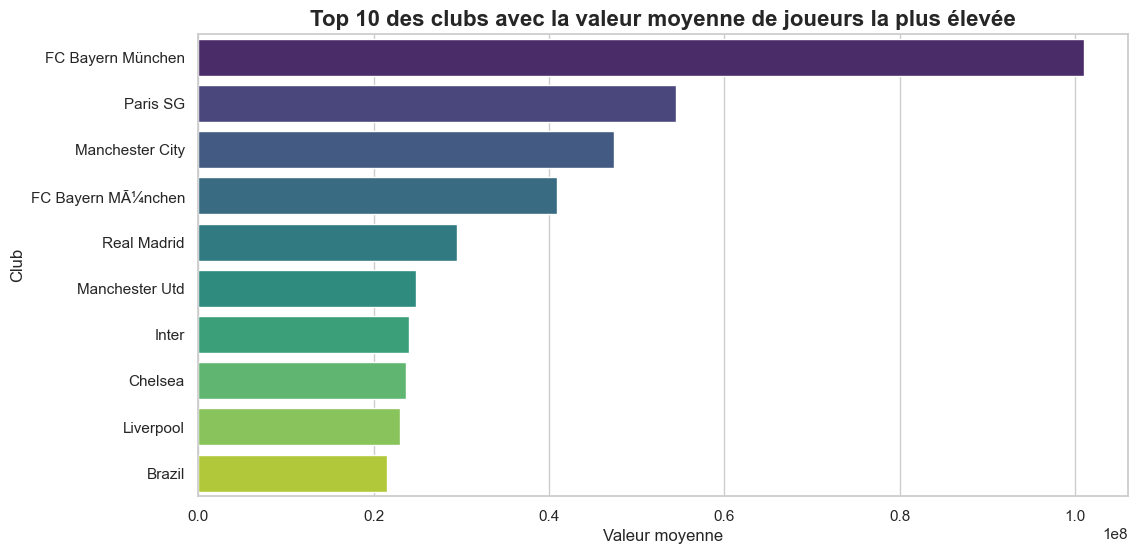

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# On nettoie les espaces invisibles dans les noms des clubs
df['club'] = df['club'].str.strip()

# On recalcule le Top 10 (maintenant que les doublons sont fusionnés)
top_clubs = df.groupby('club')['value'].mean().sort_values(ascending=False).head(10)

# On refait le graphique
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

sns.barplot(x=top_clubs.values, y=top_clubs.index, palette="viridis")

plt.title('Top 10 des clubs avec la valeur moyenne de joueurs la plus élevée', fontsize=16, fontweight='bold')
plt.xlabel('Valeur moyenne', fontsize=12)
plt.ylabel('Club', fontsize=12)

plt.show()

/var/folders/kt/5xcr79v95tl2kd96zbl6rfdw0000gn/T/ipykernel_53989/1321512676.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['club'] = df['club'].str.strip()
/var/folders/kt/5xcr79v95tl2kd96zbl6rfdw0000gn/T/ipykernel_53989/1321512676.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_clubs.values, y=top_clubs.index, palette="viridis")


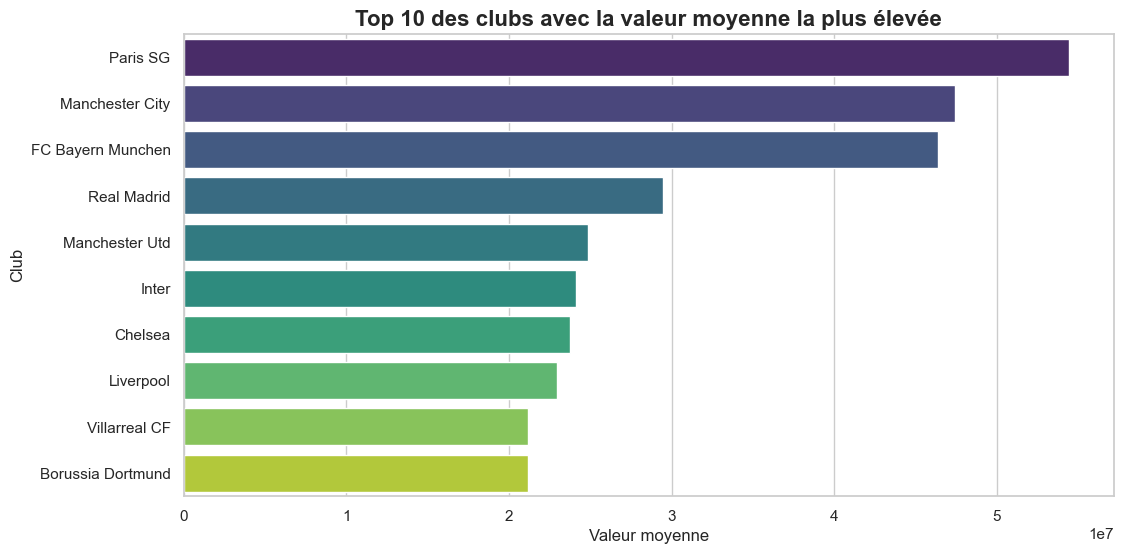

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. On aspire les espaces invisibles
df['club'] = df['club'].str.strip()

# 2. On corrige tous les Bayern bizarres
df.loc[df['club'].str.contains('Bayern', na=False), 'club'] = 'FC Bayern Munchen'

# On recalcule le Top 10
top_clubs = df.groupby('club')['value'].mean().sort_values(ascending=False).head(10)

# On refait le graphique
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
sns.barplot(x=top_clubs.values, y=top_clubs.index, palette="viridis")

plt.title('Top 10 des clubs avec la valeur moyenne la plus élevée', fontsize=16, fontweight='bold')
plt.xlabel('Valeur moyenne', fontsize=12)
plt.ylabel('Club', fontsize=12)
plt.show()

In [38]:
pepites = df[(df[('age')] <= 21) & (df['value'] <= 5000000)]

pepites_trees = pepites.sort_values(by=['sprint_speed', 'dribbling'], ascending=[False,False])

colonnes_dashboard = ['player', 'age', 'club', 'value', 'sprint_speed', 'dribbling']

pepites_trees[colonnes_dashboard].head(5)

,player,age,club,value,sprint_speed,dribbling
143,Kamaldeen Sulemana,21,Southampton,4800000.0,93,80
3797,Maximilian Beier,20,Hannover 96,1800000.0,90,70
2595,Lasso Coulibaly,20,FC NordsjÃ¦lland,65000.0,90,68
4080,Moses Otuali,21,B. Dortmund II,37500.0,90,62
5033,Marcus Hannesbo,21,AC Horsens,25000.0,90,60
